In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
from google.colab import files
uploaded = files.upload()

Saving cell2celltrain.csv to cell2celltrain.csv


In [3]:
df = pd.read_csv("cell2celltrain.csv")


In [5]:
features = ["MonthlyRevenue", "MonthlyMinutes", "TotalRecurringCharge",
            "OverageMinutes", "CustomerCareCalls"]


In [7]:
data = df[features].dropna()


In [9]:
data = df[features].dropna()
print("Shape after dropping missing rows:", data.shape)


Shape after dropping missing rows: (50891, 5)


In [10]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

In [11]:
wcss = []
silhouette_scores = []
K = range(2, 11)  # start from 2 (silhouette not defined for k=1)

In [12]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

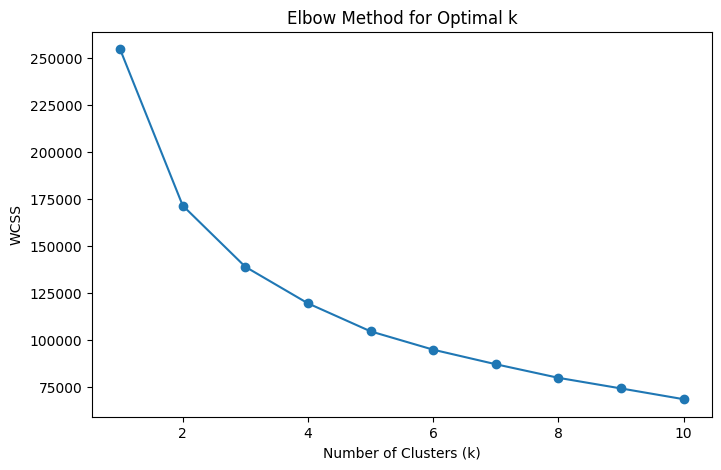

In [13]:
wcss = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")
plt.show()


In [14]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)


In [15]:
data["Cluster"] = clusters

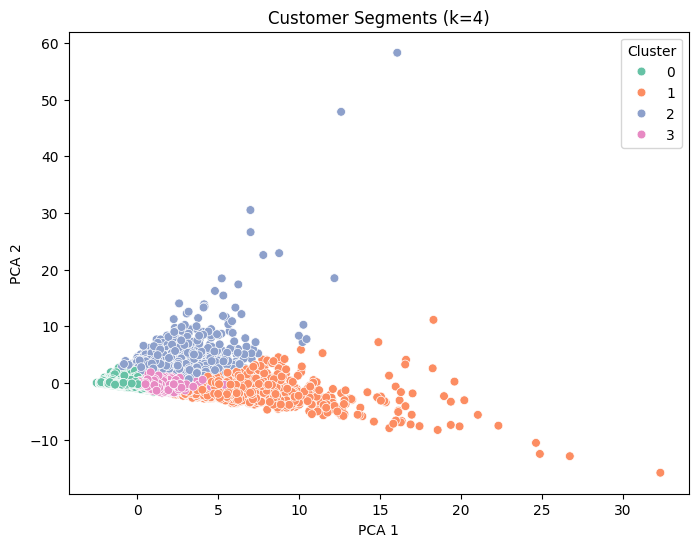

In [16]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=clusters, palette="Set2", s=40)
plt.title(f"Customer Segments (k={optimal_k})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.show()


In [17]:
cluster_summary = data.groupby("Cluster").mean()
print("\n===== Cluster Summary =====")
print(cluster_summary)



===== Cluster Summary =====
         MonthlyRevenue  MonthlyMinutes  TotalRecurringCharge  OverageMinutes  \
Cluster                                                                         
0             38.644370      260.554342             35.912806       12.811940   
1            223.743595     1989.866755             84.120712      416.100923   
2             77.353542     1254.518359             57.755940       60.897948   
3             85.565545      887.982974             66.632384       60.386657   

         CustomerCareCalls  
Cluster                     
0                 0.724145  
1                 4.153100  
2                19.721112  
3                 1.980924  


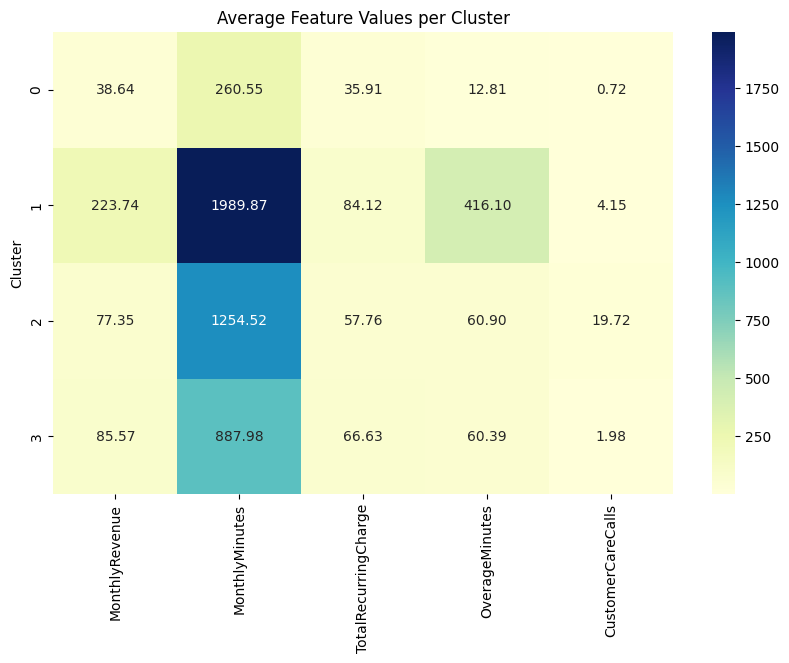

In [18]:
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_summary, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Average Feature Values per Cluster")
plt.show()

In [19]:
for cluster, row in cluster_summary.iterrows():
    print(f"\n--- Cluster {cluster} ---")
    if row["MonthlyRevenue"] > data["MonthlyRevenue"].mean():
        print("💎 High-spending customers → Promote premium plans, offer loyalty perks.")
    elif row["CustomerCareCalls"] > data["CustomerCareCalls"].mean():
        print("📞 Frequent support callers → Improve service quality, offer dedicated support.")
    elif row["OverageMinutes"] > data["OverageMinutes"].mean():
        print("⏱ Customers exceeding minutes → Upsell higher minute packages.")
    else:
        print("📉 Low-usage customers → Offer affordable basic plans or retention discounts.")


--- Cluster 0 ---
📉 Low-usage customers → Offer affordable basic plans or retention discounts.

--- Cluster 1 ---
💎 High-spending customers → Promote premium plans, offer loyalty perks.

--- Cluster 2 ---
💎 High-spending customers → Promote premium plans, offer loyalty perks.

--- Cluster 3 ---
💎 High-spending customers → Promote premium plans, offer loyalty perks.
